In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cftime
import os 

# Import modules
%reload_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')

In [2]:
# from src.netcdf import mat_to_xarray
import sys
sys.path.append('/Users/yugao/UOP/ORS-processing/src')
from util import convert_cftime_to_pandas_timestamp,  truncate_valid_hourly_data

In [3]:
case_name = 'stratus17'

In [4]:
netcdf_path = f'/Users/yugao/UOP/ORS-processing/data/processed/stratus/{case_name}_sbe37_11394.nc'
netcdf_path2 = f'/Users/yugao/UOP/ORS-processing/data/processed/stratus/{case_name}_sbe37_12257.nc'
# Load the dataset
# Replace 'your_data.nc' with the path to your dataset file
ds = xr.open_dataset(netcdf_path)
ds2 = xr.open_dataset(netcdf_path2)

In [5]:
time_coverage_start_str = ds.attrs['time_coverage_start']

In [6]:
# Parse the start date string into a cftime object
# The exact function to use depends on your calendar; assuming Gregorian here
time_coverage_start = cftime.num2date(0, units=f"days since {time_coverage_start_str}", calendar='gregorian')
# Define an end date, for instance, one year after the start
end_date = cftime.DatetimeGregorian(time_coverage_start.year + 1, time_coverage_start.month, time_coverage_start.day)
time_coverage_start, end_date

(cftime.DatetimeGregorian(2018, 4, 5, 1, 0, 0, 0, has_year_zero=False),
 cftime.DatetimeGregorian(2019, 4, 5, 0, 0, 0, 0, has_year_zero=False))

In [7]:
time_coverage_start_str = ds.attrs['time_coverage_start']

In [8]:
temp = ds.temp.data

In [9]:
truncated_ds = truncate_valid_hourly_data(ds)

### Plot segment of the time series

In [10]:
# Example definitions for the needed variables and parameters
hour_start = 0  # Starting hour index for the plot
hour_end = 720   # Ending hour index for the plot, e.g., 720 for the first month

In [11]:
# Extract serial numbers from filenames
serial_number1 = netcdf_path.split('_')[-1].split('.')[0]  # Extracts '1876' from netcdf_path
serial_number2 = netcdf_path2.split('_')[-1].split('.')[0]  # Extracts '1879' from netcdf_path2

## Compare two sensors 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ploting temp 1
ploting temp 2
ploting temp correlation
ploting sal 1
ploting sal 2
ploting sal correlation
ploting abssal 1
ploting abssal 2
ploting abssal correlation
ploting cond 1
ploting cond 2
ploting cond correlation
Plot saved as ../../img/stratus17_11394_vs_12257_comparison.png


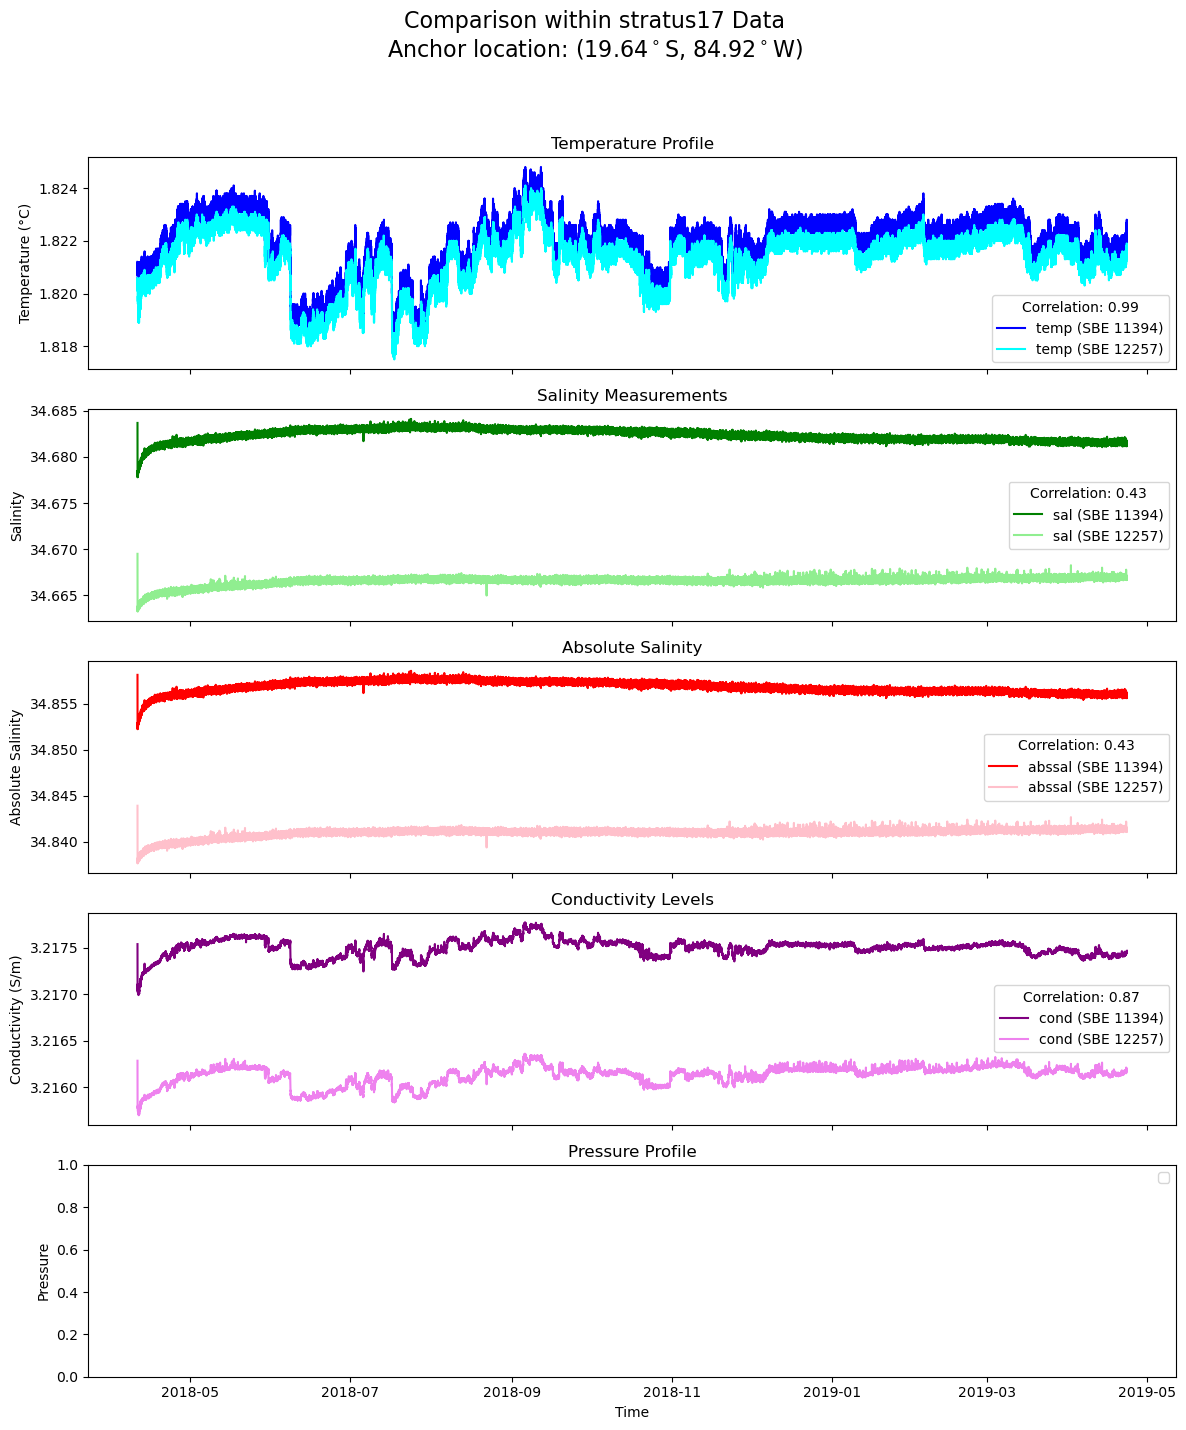

In [15]:
# Assuming truncate_valid_hourly_data and convert_cftime_to_pandas_timestamp are defined elsewhere
truncated_ds = truncate_valid_hourly_data(ds)
truncated_ds2 = truncate_valid_hourly_data(ds2)

# Converting cftime to Pandas Timestamp for both datasets
regular_time_array = truncated_ds.time
# convert_cftime_to_pandas_timestamp(truncated_ds, start_date=ds.attrs['time_coverage_start'])
regular_time_array2 = truncated_ds2.time
# convert_cftime_to_pandas_timestamp(truncated_ds2, start_date=ds2.attrs['time_coverage_start'])

variables = ['temp', 'sal', 'abssal', 'cond', 'press']  # Including 'press' for pressure
labels = ['Temperature (°C)', 'Salinity', 'Absolute Salinity', 'Conductivity (S/m)', 'Pressure']
panel_titles = ['Temperature Profile', 'Salinity Measurements', 'Absolute Salinity', 'Conductivity Levels', 'Pressure Profile']

colors = ['blue', 'green', 'red', 'purple', 'black']  # Colors for the first dataset
colors2 = ['cyan', 'lightgreen', 'pink', 'violet', 'gray']  # Colors for the second dataset

fig, axs = plt.subplots(len(variables), 1, figsize=(12, 15), sharex=True)

for i, var in enumerate(variables):
    
    if var in truncated_ds.variables:
        print(f'ploting {var} 1')
        axs[i].plot(regular_time_array[:-24], truncated_ds[var].values[:-24], label=f'{var} (SBE {serial_number1})', color=colors[i])
        
    if var in truncated_ds2.variables:
        print(f'ploting {var} 2')
        axs[i].plot(regular_time_array2[:-24], truncated_ds2[var].values[:-24], label=f'{var} (SBE {serial_number2})', color=colors2[i])
  
    if var in truncated_ds.variables and var in truncated_ds2.variables:
        print(f'ploting {var} correlation')
        # Calculating correlation
        correlation = np.corrcoef(truncated_ds[var].values, truncated_ds2[var].values)[0, 1]
        axs[i].legend(title=f'Correlation: {correlation:.2f}')
    else:
        axs[i].legend()
    
        
    axs[i].set_title(panel_titles[i] )  # Set title for each panel
    axs[i].set_ylabel(labels[i])
    # axs[i].legend(title=f'Correlation: {correlation:.2f}')
    

axs[-1].set_xlabel('Time')

# Shorter anchor position format
latitude = truncated_ds.latitude_anchor_survey if hasattr(truncated_ds, 'latitude_anchor_survey') else 0
longitude = truncated_ds.longitude_anchor_survey if hasattr(truncated_ds, 'longitude_anchor_survey') else 0
formatted_latitude = f"{-1 * latitude:.2f}"  # Format to 2 decimal places
formatted_longitude = f"{-1 * longitude:.2f}"

fig.suptitle(f'Comparison within {case_name} Data\nAnchor location: ({formatted_latitude}$^\circ$S, {formatted_longitude}$^\circ$W)', fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to accommodate the title
# plt.show()

# Save the figure
plot_path = '../../img/'
if not os.path.exists(plot_path):
    os.makedirs(plot_path)  # Ensure the directory exists
plot_filename = os.path.join(plot_path, f"{case_name}_{serial_number1}_vs_{serial_number2}_comparison.png")
plt.savefig(plot_filename)
print(f'Plot saved as {plot_filename}')


In [16]:
truncated_ds, truncated_ds2, 

(<xarray.Dataset> Size: 4MB
 Dimensions:  (time: 108722)
 Coordinates:
   * time     (time) datetime64[ns] 870kB 2018-04-11T00:10:00.019199 ... 2019-...
 Data variables:
     abssal   (time) float64 870kB 34.86 34.85 34.85 34.85 ... 34.86 34.86 34.86
     cond     (time) float64 870kB 3.218 3.217 3.217 3.217 ... 3.217 3.217 3.217
     sal      (time) float64 870kB 34.68 34.68 34.68 34.68 ... 34.68 34.68 34.68
     temp     (time) float64 870kB 1.821 1.821 1.821 1.821 ... 1.822 1.823 1.823
 Attributes: (12/49)
     time_coverage_start:                          2018-04-05T01:00:00Z
     time_coverage_end:                            2019-04-23T23:00:01Z
     time_coverage_duration:                       P383D
     latitude_anchor_survey:                       -19.638671666666667
     longitude_anchor_survey:                      -84.91831666666667
     geospatial_lat_min:                           -19.638671666666667
     ...                                           ...
     depth_water_

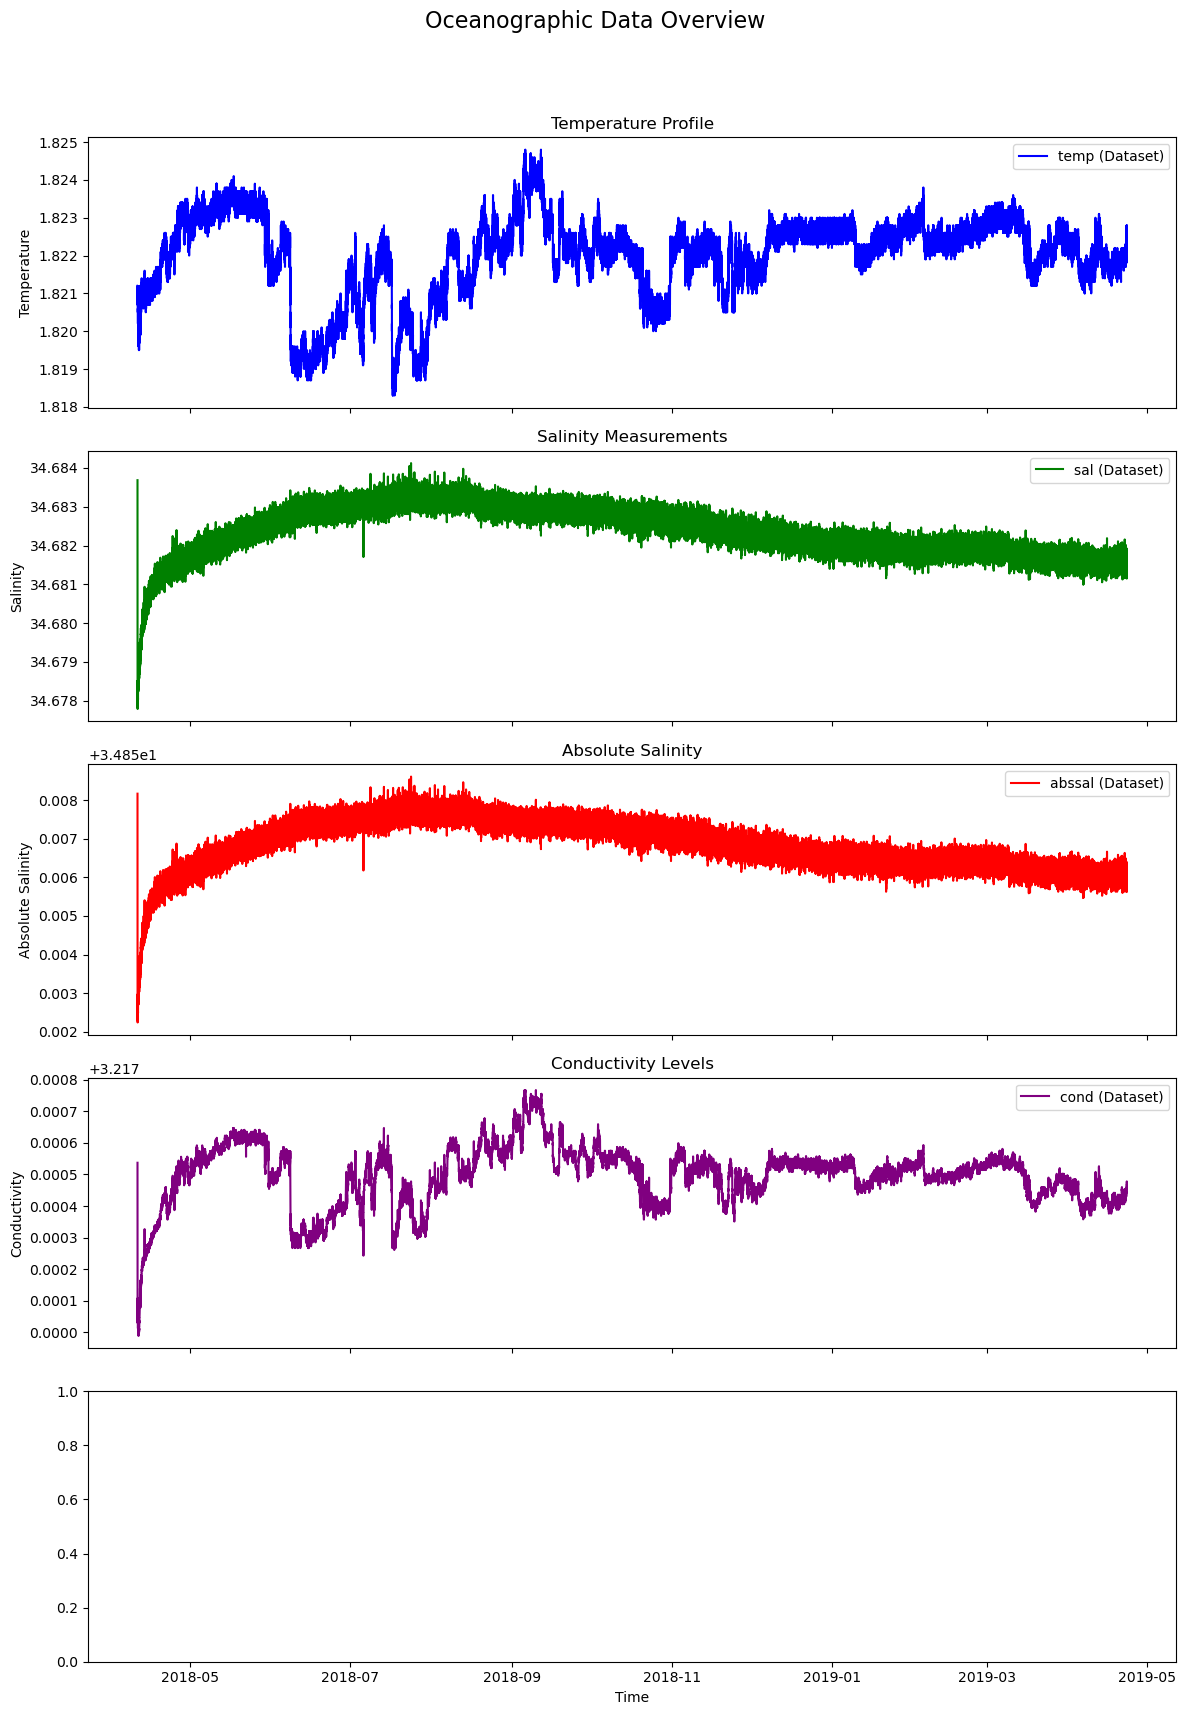

In [14]:
# Convert time format if necessary
# regular_time_array = convert_cftime_to_pandas_timestamp(truncated_ds, start_date=ds.attrs['time_coverage_start'])

# Define variables for plotting
variables = ['temp', 'sal', 'abssal', 'cond', 'press']  # Including 'press' for pressure
colors = ['blue', 'green', 'red', 'purple', 'black']  # Added black for pressure
labels = ['Temperature', 'Salinity', 'Absolute Salinity', 'Conductivity', 'Pressure']
panel_titles = ['Temperature Profile', 'Salinity Measurements', 'Absolute Salinity', 'Conductivity Levels', 'Pressure Profile']

# Prepare the plot
fig, axs = plt.subplots(len(variables), 1, figsize=(12, 18), sharex=True)  # Adjusted for an additional subplot
for i, var in enumerate(variables):
    if var in truncated_ds.variables:
        axs[i].plot(truncated_ds.time, truncated_ds[var].values, label=f'{var} (Dataset)', color=colors[i])
        axs[i].set_ylabel(labels[i])
        axs[i].set_title(panel_titles[i])
        axs[i].legend()

# Set common labels
axs[-1].set_xlabel('Time')
fig.suptitle('Oceanographic Data Overview', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save and show the plot
plot_path = 'your_plot_directory/'  # Make sure this directory exists or create it
if not os.path.exists(plot_path):
    os.makedirs(plot_path)
plot_filename = os.path.join(plot_path, 'oceanographic_data_overview.png')
# plt.savefig(plot_filename)
# plt.show()